# Influence maximization and propagation

This notebook uses the configuration, network loader, and search in `scripts/run_experiment.py`.
By default it opens the saved **latest-year, alpha=0.1, budget=20** result from
`results/experiment/results.csv` and reconstructs its starting and optimized trajectories.
Use `CONFIG = replace(ExperimentConfig(), ...)` below to inspect another setting.

Set `RUN_SEARCH = True` to call the runner's single-year search interactively; its default
allocation is **800 seconds**. The notebook displays that search in memory. For persistent
checkpoints and a grid of settings, run `python scripts/run_experiment.py` from the repository root.

The current GIP model gates each company using total shareholder pressure (`p > tau`),
then returns influence to other shareholders with direct self-return removed. Municipal
bounds change at each update. Defaults are tempered weights (`beta=0.5`), `tau=0`, and
exactly 20 updates. The objective sums population-weighted state with discount
`(1-gamma)^t`, including the seed state at `t=0` once.

Coverage below counts municipalities with positive state, including seeds, within the
filtered experiment network. **Active now**, **ever reached**, and **discounted score**
measure different things; full reach can coexist with a small or declining state.


In [1]:
import json
import os
import sys
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "scripts/run_experiment.py").is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not find the project root")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.run_experiment import (
    DATA_DIR, DEFAULT_OUTPUT_DIR, ExperimentConfig, available_years,
    instance_mask, load_results, load_year_model, parameter_values, run_year,
)
from src.gip_model import gip

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)


In [2]:
YEARS = available_years(DATA_DIR)
if not YEARS:
    raise FileNotFoundError("Run python src/prepare_data.py first")
YEAR = max(YEARS)
CONFIG = replace(ExperimentConfig(), alpha=0.1, seed_budget=20)
RUN_SEARCH = False
RESULTS_DIR = Path(os.environ.get("INFLUENCE_RESULTS_DIR", str(DEFAULT_OUTPUT_DIR))).expanduser().resolve()
RESULTS_PATH = RESULTS_DIR / "results.csv"

display(pd.Series({"year": YEAR, **parameter_values(CONFIG)}, name="value").to_frame())


,value
year,2023.00
alpha,0.10
seed_budget,20.00
edge_weight_beta,0.50
node_weight_beta,0.50
min_edge_size,2.00
edge_weight_mean,1.00
node_weight_mean,1.00
h0,1.00
l0,1.00


In [3]:
model = load_year_model(YEAR, CONFIG, data_dir=DATA_DIR)
node_ids = model["node_ids"]
print(f"Year {YEAR}: {len(node_ids):,} municipalities, "
      f"{model['incidence'].shape[1]:,} companies, {model['incidence_count']:,} incidences")
print(f"Minimum company size: {CONFIG.min_edge_size}; "
      f"mean company weight: {model['edge_weights'].mean():.3f}; "
      f"mean municipality weight: {model['node_weights'].mean():.3f}")


Year 2023: 7,744 municipalities, 4,040 companies, 105,108 incidences
Minimum company size: 2; mean company weight: 1.000; mean municipality weight: 1.000


In [4]:
def simulate_ids(seed_ids):
    seed_ids = [int(value) for value in seed_ids]
    if len(seed_ids) != CONFIG.seed_budget or len(set(seed_ids)) != len(seed_ids):
        raise ValueError("Seed IDs must be unique and match CONFIG.seed_budget")
    missing = set(seed_ids) - set(node_ids)
    if missing:
        raise ValueError(f"Seed municipalities missing from this network: {sorted(missing)}")
    seed_state = np.isin(node_ids, seed_ids).astype(float) * CONFIG.seed_intensity
    return gip(
        model["incidence"], model["edge_weights"], seed_state, CONFIG.gip_parameters,
        node_weights=model["node_weights"], stress_level=CONFIG.stress_level,
        alpha=CONFIG.alpha, horizon=CONFIG.horizon, max_iter=CONFIG.max_iter,
    )


def propagation_table(diffusion):
    states = np.asarray(diffusion.states)
    active = states > 0
    reached = np.logical_or.accumulate(active, axis=0)
    weighted_state = states @ model["node_weights"]
    steps = np.arange(len(states))
    return pd.DataFrame({
        "step": steps,
        "active_now": active.sum(axis=1),
        "active_now_pct": 100 * active.mean(axis=1),
        "ever_reached": reached.sum(axis=1),
        "ever_reached_pct": 100 * reached.mean(axis=1),
        "population_weighted_state": weighted_state,
        "discounted_increment": (1 - CONFIG.gamma) ** steps * weighted_state,
        "cumulative_score": diffusion.spread_history,
    }).set_index("step")


In [5]:
if RUN_SEARCH:
    summary, _, _ = run_year(YEAR, CONFIG, verbose=True)
    start_ids, finish_ids = summary["start_list"], summary["finish_list"]
    start_score, finish_score = summary["initial_spread"], summary["best_spread"]
    print(f"Search completed in {summary['search_elapsed_seconds']:.1f}s "
          f"with {summary['search_restarts']} restarts")
else:
    saved_results = load_results(RESULTS_PATH)
    matches = saved_results.loc[instance_mask(saved_results, {"year": YEAR, **parameter_values(CONFIG)})]
    if len(matches) != 1:
        raise ValueError(
            f"Expected one saved result for this configuration at {RESULTS_PATH}; found {len(matches)}. "
            "Choose a saved CONFIG, run scripts/run_experiment.py, or set RUN_SEARCH=True."
        )
    saved_result = matches.iloc[0]
    start_ids = json.loads(saved_result["start_list"])
    finish_ids = json.loads(saved_result["finish_list"])
    start_score, finish_score = saved_result["start_spread"], saved_result["finish_spread"]
    print(f"Loaded saved result from {RESULTS_PATH}")

selected_ids = [int(value) for value in finish_ids]
gain_pct = 100 * (finish_score / start_score - 1) if start_score else np.nan
display(pd.Series({
    "starting score": start_score, "optimized score": finish_score,
    "optimization gain (%)": gain_pct,
    "retained seeds": len(set(start_ids) & set(finish_ids)),
    "replaced seeds": len(set(start_ids) - set(finish_ids)),
}, name="value").to_frame())


Loaded saved result from /Users/matteobergamaschi/Desktop/rete_ipl_git/results/experiment/results.csv


,value
starting score,16524.701739
optimized score,21752.360420
optimization gain (%),31.635419
retained seeds,5.000000
replaced seeds,15.000000


In [6]:
start_diffusion = simulate_ids(start_ids)
best_diffusion = simulate_ids(finish_ids)
np.testing.assert_allclose(
    [start_diffusion.total_spread, best_diffusion.total_spread],
    [start_score, finish_score], rtol=1e-12, atol=1e-9,
    err_msg="Stored scores do not match the current data and propagation settings",
)
trajectories = {
    "Starting seeds": propagation_table(start_diffusion),
    "Optimized seeds": propagation_table(best_diffusion),
}
coverage_summary = pd.DataFrame([
    {
        "seed set": label,
        "score": diffusion.total_spread,
        "updates": diffusion.iterations,
        "stopping reason": diffusion.stopping_reason,
        "active at final step": int(table.iloc[-1]["active_now"]),
        "ever reached": int(table.iloc[-1]["ever_reached"]),
        "ever reached (%)": table.iloc[-1]["ever_reached_pct"],
        "complete reach": int(table.iloc[-1]["ever_reached"]) == len(node_ids),
    }
    for (label, table), diffusion in zip(trajectories.items(), [start_diffusion, best_diffusion])
]).set_index("seed set")
display(coverage_summary)
display(pd.concat(trajectories, names=["seed set", "step"]))


,score,updates,stopping reason,active at final step,ever reached,ever reached (%),complete reach
seed set,,,,,,,
Starting seeds,16524.701739,20,fixed_horizon,7515,7515,97.042872,False
Optimized seeds,21752.360420,20,fixed_horizon,7515,7515,97.042872,False


active_now  active_now_pct  ever_reached  \
seed set        step                                             
Starting seeds  0             20        0.258264            20   
                1           2640       34.090909          2643   
                2           6213       80.229855          6213   
                3           7486       96.668388          7486   
                4           7515       97.042872          7515   
                5           7515       97.042872          7515   
                6           7515       97.042872          7515   
                7           7515       97.042872          7515   
                8           7515       97.042872          7515   
                9           7515       97.042872          7515   
                10          7515       97.042872          7515   
                11          7515       97.042872          7515   
                12          7515       97.042872          7515   
                13          7515       97.042872          7515   
                14          7515       97.042872          7515   
                15          7515       97.042872          7515   
                16          7515       97.042872          7515   
                17          7515       97.042872          7515   
                18          7515       97.042872          7515   
                19          7515       97.042872          7515   
                20          7515       97.042872          7515   
Optimized seeds 0             20        0.258264            20   
                1           3919       50.606921          3927   
                2           7178       92.691116          7178   
                3           7506       96.926653          7506   
                4           7515       97.042872          7515   
                5           7515       97.042872          7515   
                6           7515       97.042872          7515   
                7           7515       97.042872          7515   
                8           7515       97.042872          7515   
                9           7515       97.042872          7515   
                10          7515       97.042872          7515   
                11          7515       97.042872          7515   
                12          7515       97.042872          7515   
                13          7515       97.042872          7515   
                14          7515       97.042872          7515   
                15          7515       97.042872          7515   
                16          7515       97.042872          7515   
                17          7515       97.042872          7515   
                18          7515       97.042872          7515   
                19          7515       97.042872          7515   
                20          7515       97.042872          7515   

                      ever_reached_pct  population_weighted_state  \
seed set        step                                                
Starting seeds  0             0.258264               9.266066e+01   
                1            34.129649               1.132214e+04   
                2            80.229855               6.061608e+03   
                3            96.668388               1.495618e+03   
                4            97.042872               3.023295e+02   
                5            97.042872               6.046911e+01   
                6            97.042872               1.209382e+01   
                7            97.042872               2.418765e+00   
                8            97.042872               4.837530e-01   
                9            97.042872               9.675059e-02   
                10           97.042872               1.935012e-02   
                11           97.042872               3.870024e-03   
                12           97.042872               7.740047e-04   
                13           97.042872               1.548009e-04   
             

In [7]:
selected = model["node_audit"].reindex(selected_ids).reset_index()
selected.insert(0, "selection_rank", np.arange(1, len(selected) + 1))
selected["status"] = ["retained" if value in start_ids else "added" for value in selected_ids]
selected["structural_degree"] = selected["municipality_id"].map(model["structural_degree"])
display(selected[[
    "selection_rank", "municipality_id", "municipality_name", "population",
    "node_weight", "structural_degree", "status",
]])


,selection_rank,municipality_id,municipality_name,population,node_weight,structural_degree,status
0,1,761890177,COMUNE DI BRESCIA,198688.000,6.970358,321,retained
1,2,145920351,COMUNE DI REGGIO NELL'EMILIA,171342.000,6.472934,284,retained
2,3,215150236,COMUNE DI VERONA,255643.000,7.906536,74,added
3,4,2438750586,ROMA CAPITALE,2754719.000,25.954218,45,added
4,5,1232710374,COMUNE DI BOLOGNA,390518.000,9.772143,163,added
5,6,168650307,COMUNE DI UDINE,98430.000,4.906062,578,retained
6,7,516890241,COMUNE DI VICENZA,110830.000,5.205926,486,retained
7,8,224000125,COMUNE DI BUSTO ARSIZIO,83439.000,4.517039,22,added
8,9,80005990611,COMUNE DI TEANO,11144.000,1.650782,20,added
9,10,172340069,COMUNE DI CASALE MONFERRATO,32217.000,2.806802,134,added


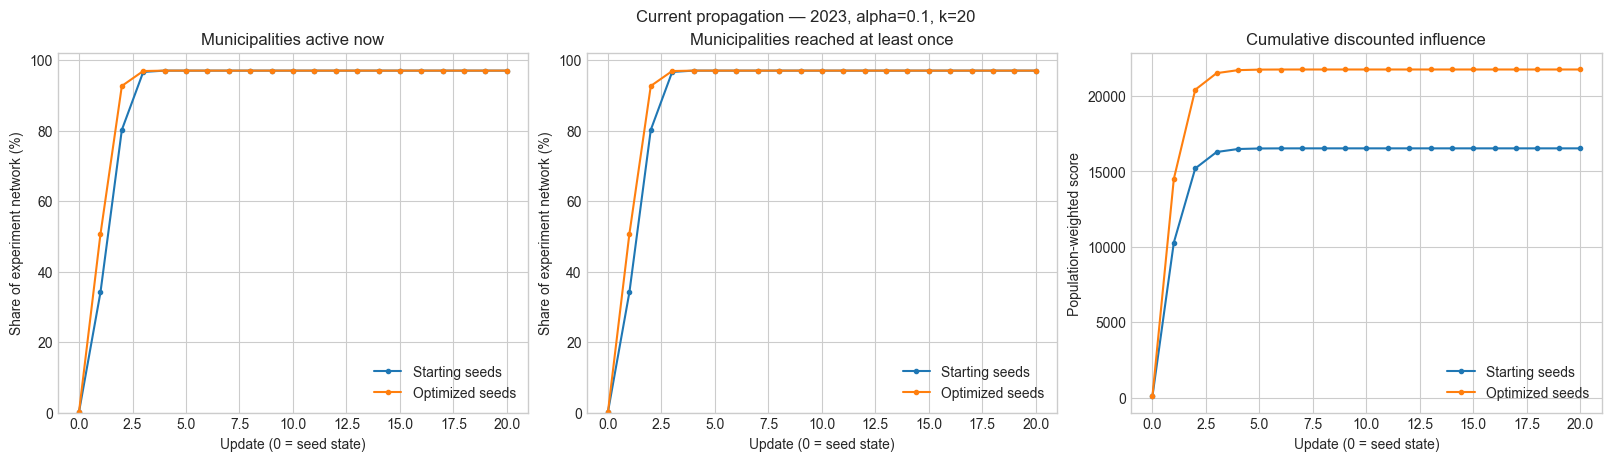

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
for label, table in trajectories.items():
    axes[0].plot(table.index, table["active_now_pct"], marker="o", markersize=3, label=label)
    axes[1].plot(table.index, table["ever_reached_pct"], marker="o", markersize=3, label=label)
    axes[2].plot(table.index, table["cumulative_score"], marker="o", markersize=3, label=label)
axes[0].set(title="Municipalities active now", ylabel="Share of experiment network (%)", ylim=(0, 102))
axes[1].set(title="Municipalities reached at least once", ylabel="Share of experiment network (%)", ylim=(0, 102))
axes[2].set(title="Cumulative discounted influence", ylabel="Population-weighted score")
for axis in axes:
    axis.set_xlabel("Update (0 = seed state)")
    axis.legend()
fig.suptitle(f"Current propagation — {YEAR}, alpha={CONFIG.alpha:g}, k={CONFIG.seed_budget}")
plt.show()
